<a href="https://colab.research.google.com/github/esprado1976/nba_stats/blob/main/Curiosidad_NBA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install nba_api pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.6/322.6 kB 8.3 MB/s eta 0:00:00


In [15]:
import pandas as pd
from nba_api.stats.endpoints import playbyplayv3
from nba_api.stats.static import teams

# 1. Obtener los datos puros de la API V3
GAME_ID = '0042500402'
pbp = playbyplayv3.PlayByPlayV3(game_id=GAME_ID)
data_json = pbp.get_dict()
actions_list = data_json['game']['actions']
df = pd.DataFrame(actions_list)

print("--- 1. COLUMNAS DISPONIBLES EN EL DATAFRAME ---")
print(df.columns.tolist())
print("\n" + "="*50 + "\n")

# 2. Filtrar un par de jugadas de los Spurs para ver el contenido real
SPURS_ID = teams.find_teams_by_full_name('San Antonio Spurs')[0]['id']
df_spurs = df[df['teamId'] == SPURS_ID]

print("--- 2. EJEMPLO DE FILAS PUERAS DE LOS SPURS (Primeras 3) ---")
# Mostramos columnas clave para entender cómo registran los tiros y los nombres
columnas_clave = ['period', 'clock', 'actionType', 'subType', 'shotResult', 'playerNameI', 'pointsTotal']
# Usamos un filtro flexible por si alguna columna de estas varía en su nombre exacto
columnas_validas = [c for c in columnas_clave if c in df_spurs.columns]
print(df_spurs[columnas_validas].head(3).to_string())
print("\n" + "="*50 + "\n")

print("--- 3. VALORES ÚNICOS DE 'actionType' (Para ver cómo llaman a los tiros) ---")
if 'actionType' in df_spurs.columns:
    print(df_spurs['actionType'].unique())
else:
    print("No se encontró la columna actionType")
print("\n" + "="*50 + "\n")

print("--- 4. JUGADORES DETECTADOS EN EL EQUIPO ---")
if 'playerNameI' in df_spurs.columns:
    print(df_spurs['playerNameI'].value_counts())
elif 'playerName' in df_spurs.columns:
    print(df_spurs['playerName'].value_counts())

--- 1. COLUMNAS DISPONIBLES EN EL DATAFRAME ---
['actionNumber', 'clock', 'period', 'teamId', 'teamTricode', 'personId', 'playerName', 'playerNameI', 'xLegacy', 'yLegacy', 'shotDistance', 'shotResult', 'isFieldGoal', 'scoreHome', 'scoreAway', 'pointsTotal', 'location', 'description', 'actionType', 'subType', 'videoAvailable', 'shotValue', 'actionId']


--- 2. EJEMPLO DE FILAS PUERAS DE LOS SPURS (Primeras 3) ---
   period        clock  actionType            subType shotResult    playerNameI  pointsTotal
1       1  PT12M00.00S   Jump Ball                                V. Wembanyama            0
2       1  PT11M36.00S   Made Shot          Jump Shot       Made     D. Vassell            3
5       1  PT10M55.00S  Free Throw  Free Throw 1 of 2             J. Champagnie            6


--- 3. VALORES ÚNICOS DE 'actionType' (Para ver cómo llaman a los tiros) ---
['Jump Ball' 'Made Shot' 'Free Throw' 'Rebound' 'Missed Shot' 'Foul' ''
 'Substitution' 'Turnover']


--- 4. JUGADORES DETECTADOS EN 

¡Datos descargados con éxito! Total de tiros registrados: 78


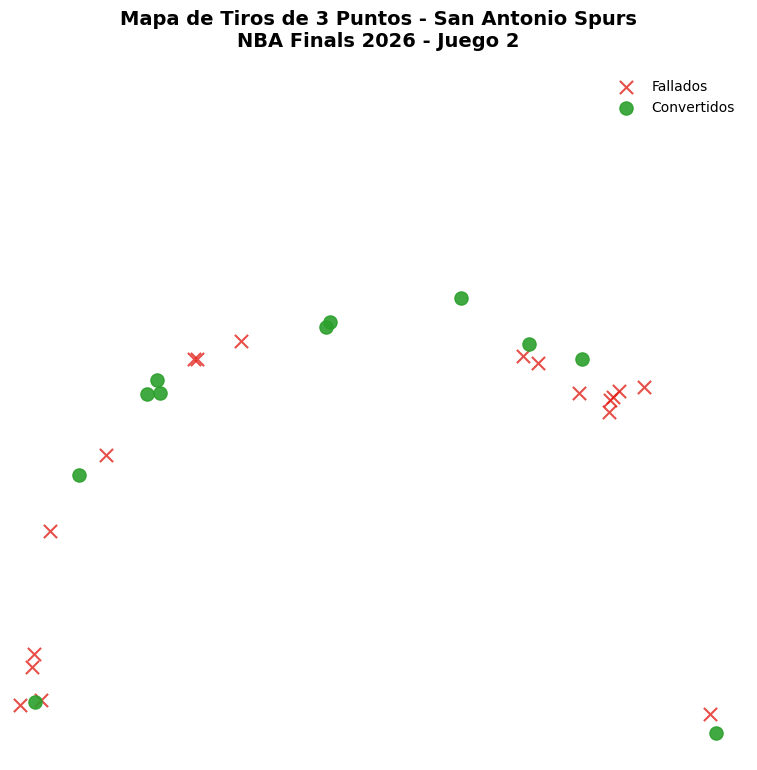

In [3]:
import time
import pandas as pd
import matplotlib.pyplot as plt
from nba_api.stats.endpoints import shotchartdetail
from nba_api.stats.static import teams

# 1. Obtener el ID de San Antonio Spurs
SPURS_ID = teams.find_teams_by_full_name('San Antonio Spurs')[0]['id']

# ID del Juego 2 de las Finales 2026
GAME_ID = '0042500402'

# 2. Llamar al endpoint con los parámetros corregidos
try:
    shot_data = shotchartdetail.ShotChartDetail(
        team_id=SPURS_ID,
        player_id=0,                       # 0 para traer a todo el equipo
        game_id_nullable=GAME_ID,
        context_measure_simple='FGA',       # Intentos de tiro de campo
        season_nullable='2025-26',         # <--- PARÁMETRO CORREGIDO
        season_type_all_star='Playoffs'
    )
    # Extraemos el DataFrame principal
    df_shots = shot_data.get_data_frames()[0]
    print(f"¡Datos descargados con éxito! Total de tiros registrados: {len(df_shots)}")

except Exception as e:
    print(f"Error al conectar con la API: {e}")
    df_shots = pd.DataFrame() # Creamos un dataframe vacío para que no rompa abajo si falla

# 3. Solo ejecutamos el gráfico si el DataFrame tiene datos
if not df_shots.empty:
    # Filtrar solo los intentos de 3 puntos
    df_3pm = df_shots[df_shots['SHOT_TYPE'] == '3PT Field Goal'].copy()

    # Separar los triples metidos de los errados
    aciertos = df_3pm[df_3pm['SHOT_MADE_FLAG'] == 1]
    fallos = df_3pm[df_3pm['SHOT_MADE_FLAG'] == 0]

    # 4. Crear la visualización
    plt.figure(figsize=(10, 9))

    # Graficar los puntos
    plt.scatter(fallos['LOC_X'], fallos['LOC_Y'], color='#E2231A', marker='x', s=90, label='Fallados', alpha=0.8)
    plt.scatter(aciertos['LOC_X'], aciertos['LOC_Y'], color='#2CA02C', marker='o', s=90, label='Convertidos', alpha=0.9)

    # Límites de la media cancha
    plt.xlim(-250, 250)
    plt.ylim(-47, 423)
    plt.gca().set_aspect('equal', adjustable='box')

    # Estética
    plt.title('Mapa de Tiros de 3 Puntos - San Antonio Spurs\nNBA Finals 2026 - Juego 2', fontsize=14, pad=15, fontweight='bold')
    plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
    plt.axis('off')

    plt.show()
else:
    print("No se pudieron procesar los datos porque el DataFrame está vacío. Revisá la conexión.")

Generando 7 mapas individuales...


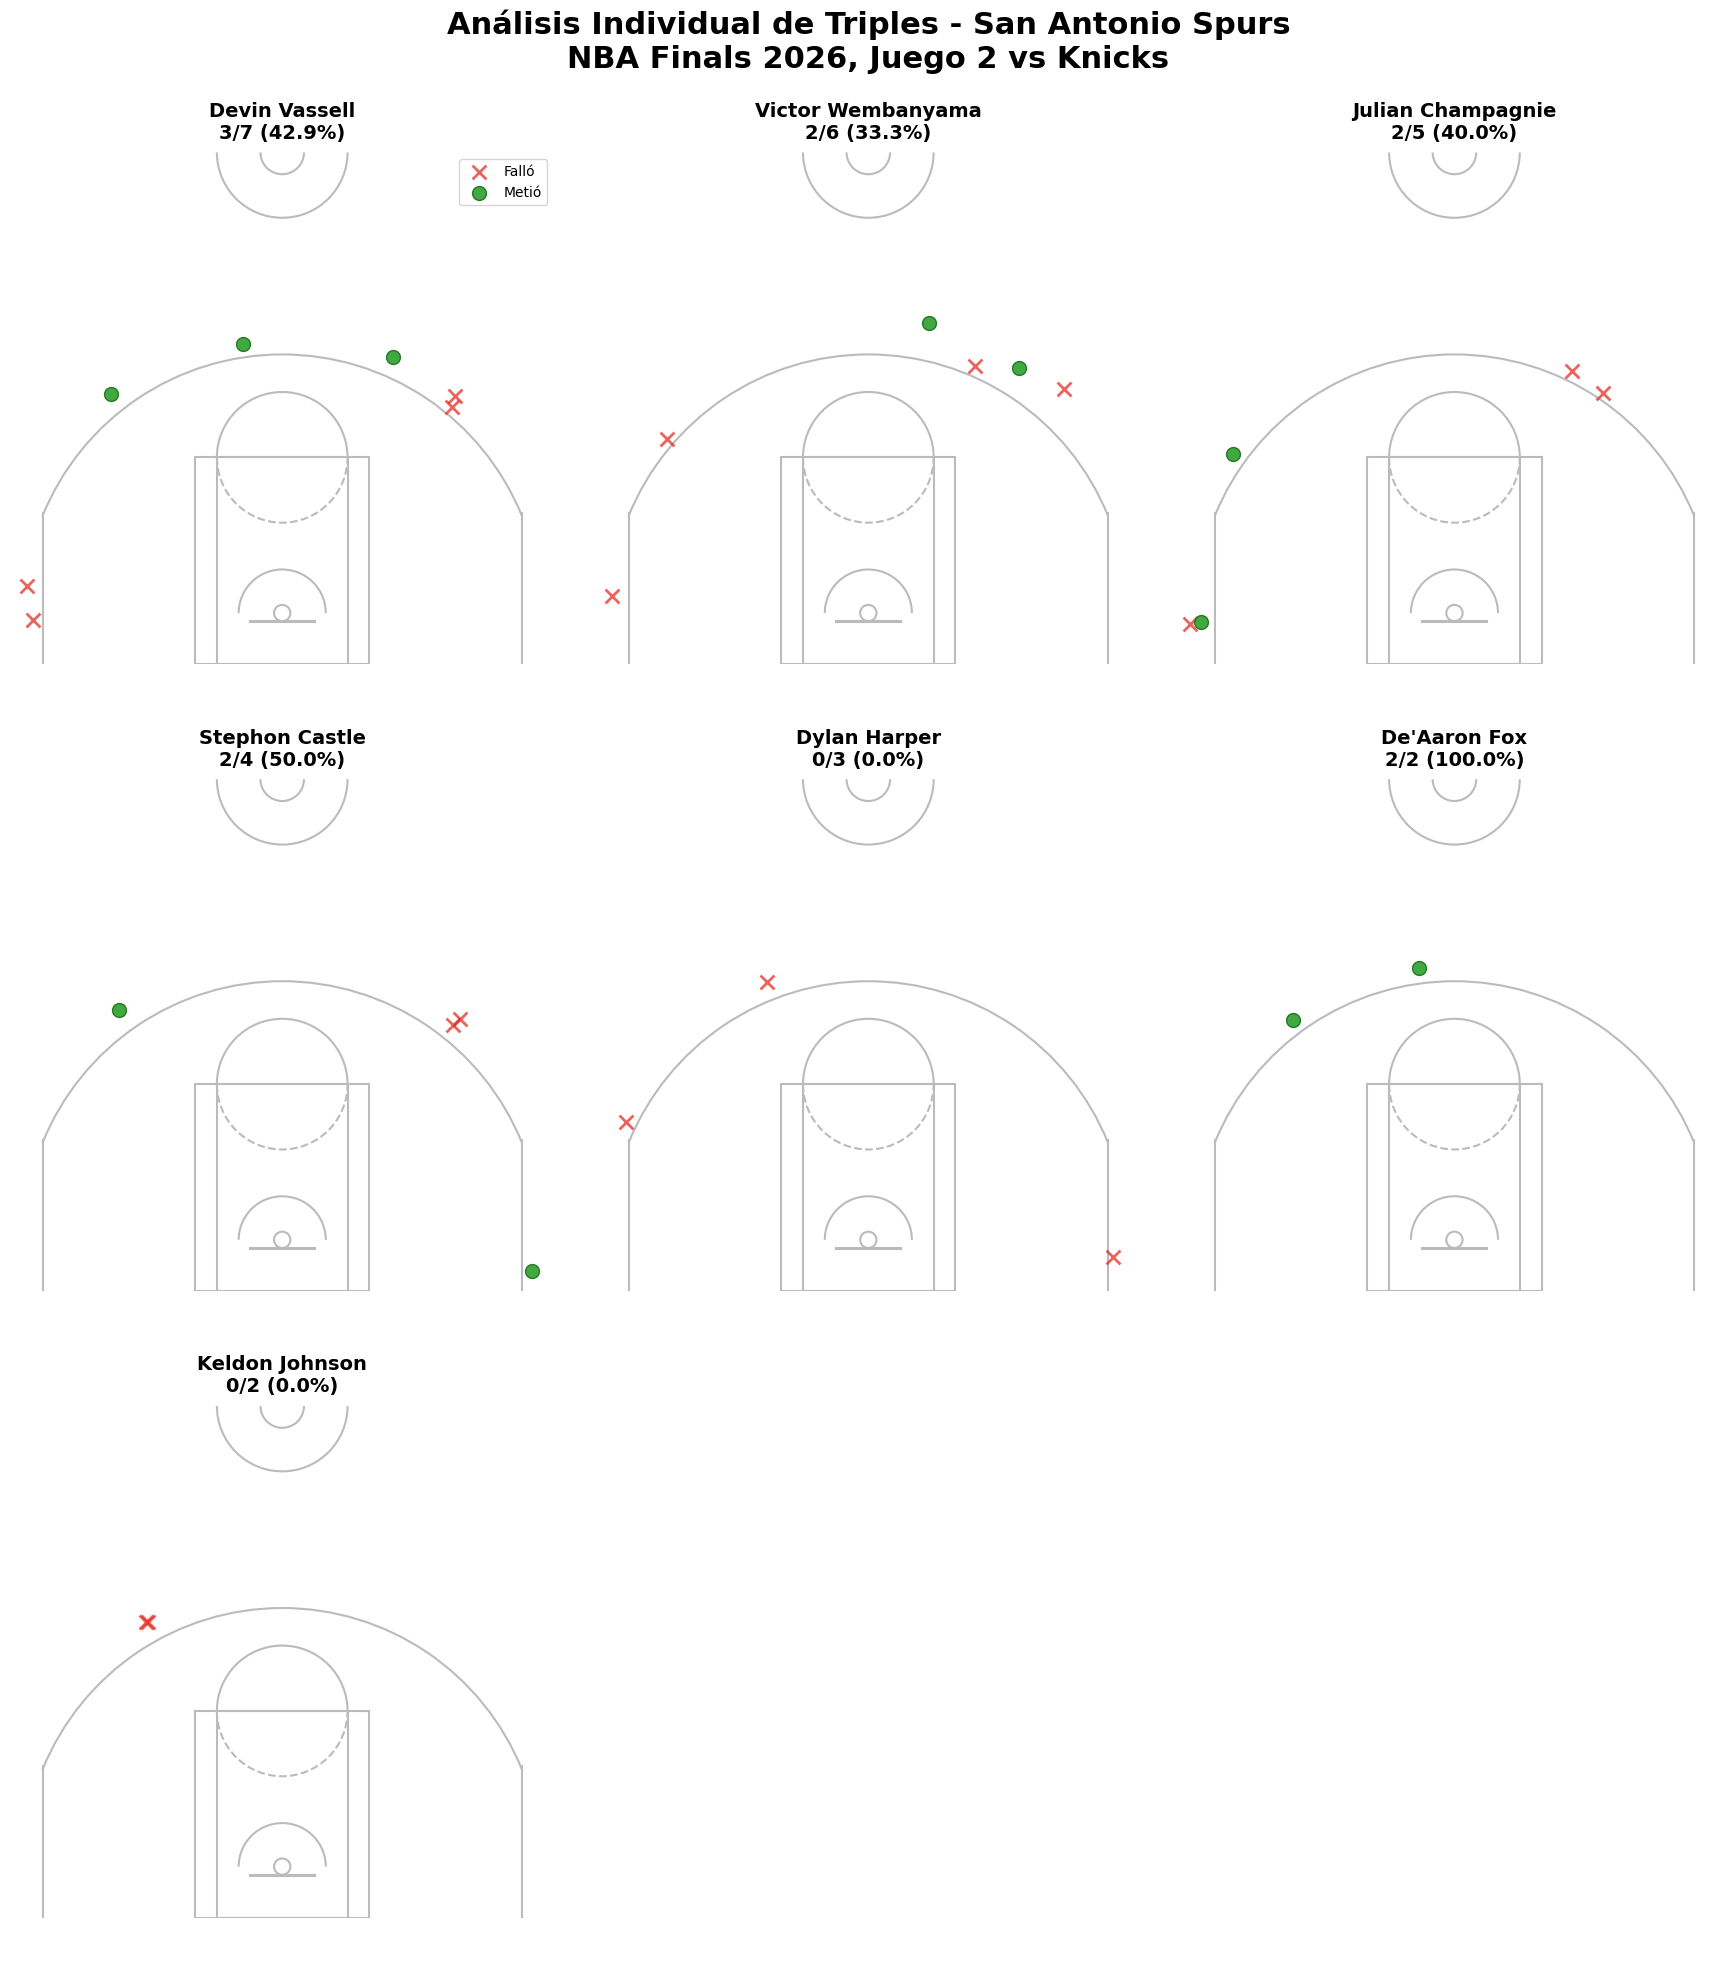

In [4]:
import time
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, Arc
from nba_api.stats.endpoints import shotchartdetail
from nba_api.stats.static import teams

# ==============================================================================
# FUNCIÓN MAESTRA: Dibujar la cancha de la NBA
# ==============================================================================
def draw_court(ax=None, color='black', lw=2, outer_lines=False):
    """Dibuja una media cancha de la NBA reglamentaria."""
    if ax is None:
        ax = plt.gca()

    # El aro (coordenada 0,0, radio 7.5 unidades)
    hoop = Circle((0, 0), radius=7.5, linewidth=lw, color=color, fill=False)
    # El tablero
    backboard = Rectangle((-30, -7.5), 60, -1, linewidth=lw, color=color)

    # La zona pintada (La Llave)
    outer_box = Rectangle((-80, -47), 160, 190, linewidth=lw, color=color, fill=False)
    inner_box = Rectangle((-60, -47), 120, 190, linewidth=lw, color=color, fill=False)

    # Semicírculo de la línea de tiros libres
    top_free_throw = Arc((0, 143), 120, 120, theta1=0, theta2=180, linewidth=lw, color=color, fill=False)
    bottom_free_throw = Arc((0, 143), 120, 120, theta1=180, theta2=360, linewidth=lw, color=color, linestyle='dashed')
    # Semicírculo de restricción (bajo el aro)
    restricted = Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw, color=color)

    # LÍNEA DE 3 PUNTOS (Lo más complejo)
    # 1. Las líneas rectas laterales (corners)
    corner_three_a = Rectangle((-220, -47), 0, 140, linewidth=lw, color=color)
    corner_three_b = Rectangle((220, -47), 0, 140, linewidth=lw, color=color)
    # 2. El arco central (que conecta las rectas)
    three_arc = Arc((0, 0), 475, 475, theta1=22, theta2=158, linewidth=lw, color=color)

    # Círculo central (media cancha)
    center_outer_arc = Arc((0, 423), 120, 120, theta1=180, theta2=360, linewidth=lw, color=color)
    center_inner_arc = Arc((0, 423), 40, 40, theta1=180, theta2=360, linewidth=lw, color=color)

    # Lista de elementos a dibujar
    court_elements = [hoop, backboard, outer_box, inner_box, top_free_throw,
                      bottom_free_throw, restricted, corner_three_a,
                      corner_three_b, three_arc, center_outer_arc, center_inner_arc]

    if outer_lines:
        outer_lines_rect = Rectangle((-250, -47), 500, 470, linewidth=lw, color=color, fill=False)
        court_elements.append(outer_lines_rect)

    # Añadir todos los parches al gráfico
    for element in court_elements:
        ax.add_patch(element)

    return ax

# ==============================================================================
# 1. Obtener y Procesar Datos (Igual que antes)
# ==============================================================================
SPURS_ID = teams.find_teams_by_full_name('San Antonio Spurs')[0]['id']
GAME_ID = '0042500402' # Finales 2026, Juego 2

try:
    shot_data = shotchartdetail.ShotChartDetail(
        team_id=SPURS_ID,
        player_id=0,
        game_id_nullable=GAME_ID,
        context_measure_simple='FGA',
        season_nullable='2025-26',
        season_type_all_star='Playoffs'
    )
    df_shots = shot_data.get_data_frames()[0]
except Exception as e:
    print(f"Error API: {e}")
    df_shots = pd.DataFrame()

# ==============================================================================
# 2. Mosaico de Mapas por Jugador
# ==============================================================================
if not df_shots.empty:
    # Filtrar solo triples
    df_3pm = df_shots[df_shots['SHOT_TYPE'] == '3PT Field Goal'].copy()

    # Identificar qué jugadores tiraron triples (y ordenarlos por cantidad de intentos)
    jugadores_tiradores = df_3pm['PLAYER_NAME'].value_counts().index.tolist()
    num_jugadores = len(jugadores_tiradores)

    # Configurar la grilla de subplots (dinámica)
    cols = 3
    rows = (num_jugadores + cols - 1) // cols # Cálculo de filas necesarias
    fig, axes = plt.subplots(rows, cols, figsize=(cols*6, rows*6.5))
    axes = axes.flatten() # Aplanar para iterar fácil

    print(f"Generando {num_jugadores} mapas individuales...")

    for i, player in enumerate(jugadores_tiradores):
        ax = axes[i]

        # Datos específicos del jugador
        player_shots = df_3pm[df_3pm['PLAYER_NAME'] == player]

        # --- EL TRUCO: Dibujar la cancha de fondo en cada subplot ---
        draw_court(ax, color='#bbbbbb', lw=1.5) # Usamos un gris suave para el fondo

        # Graficar los tiros del jugador
        aciertos = player_shots[player_shots['SHOT_MADE_FLAG'] == 1]
        fallos = player_shots[player_shots['SHOT_MADE_FLAG'] == 0]

        ax.scatter(fallos['LOC_X'], fallos['LOC_Y'], color='#E2231A', marker='x', s=100, label='Falló', alpha=0.7, linewidth=2)
        ax.scatter(aciertos['LOC_X'], aciertos['LOC_Y'], color='#2CA02C', marker='o', s=100, label='Metió', alpha=0.9, edgecolor='#1a6e1a')

        # Estadísticas individuales para el título
        intentos = len(player_shots)
        convertidos = len(aciertos)
        porcentaje = (convertidos / intentos * 100) if intentos > 0 else 0

        # Configuración estética de cada mini-mapa
        ax.set_title(f"{player}\n{convertidos}/{intentos} ({porcentaje:.1f}%)", fontsize=14, fontweight='bold', pad=10)
        ax.set_xlim(-250, 250)
        ax.set_ylim(-47, 423)
        ax.set_aspect('equal')
        ax.axis('off') # Quitar ejes cartesianos

    # Apagar los subplots que queden vacíos (si num_jugadores no es múltiplo de cols)
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout(pad=3)
    plt.suptitle(f'Análisis Individual de Triples - San Antonio Spurs\nNBA Finals 2026, Juego 2 vs Knicks', fontsize=22, fontweight='bold', y=1.02)

    # Mostrar la leyenda solo en el primer gráfico para no saturar
    axes[0].legend(loc='upper right', fontsize=10, frameon=True, facecolor='white')

    plt.show()

else:
    print("Sin datos para graficar.")

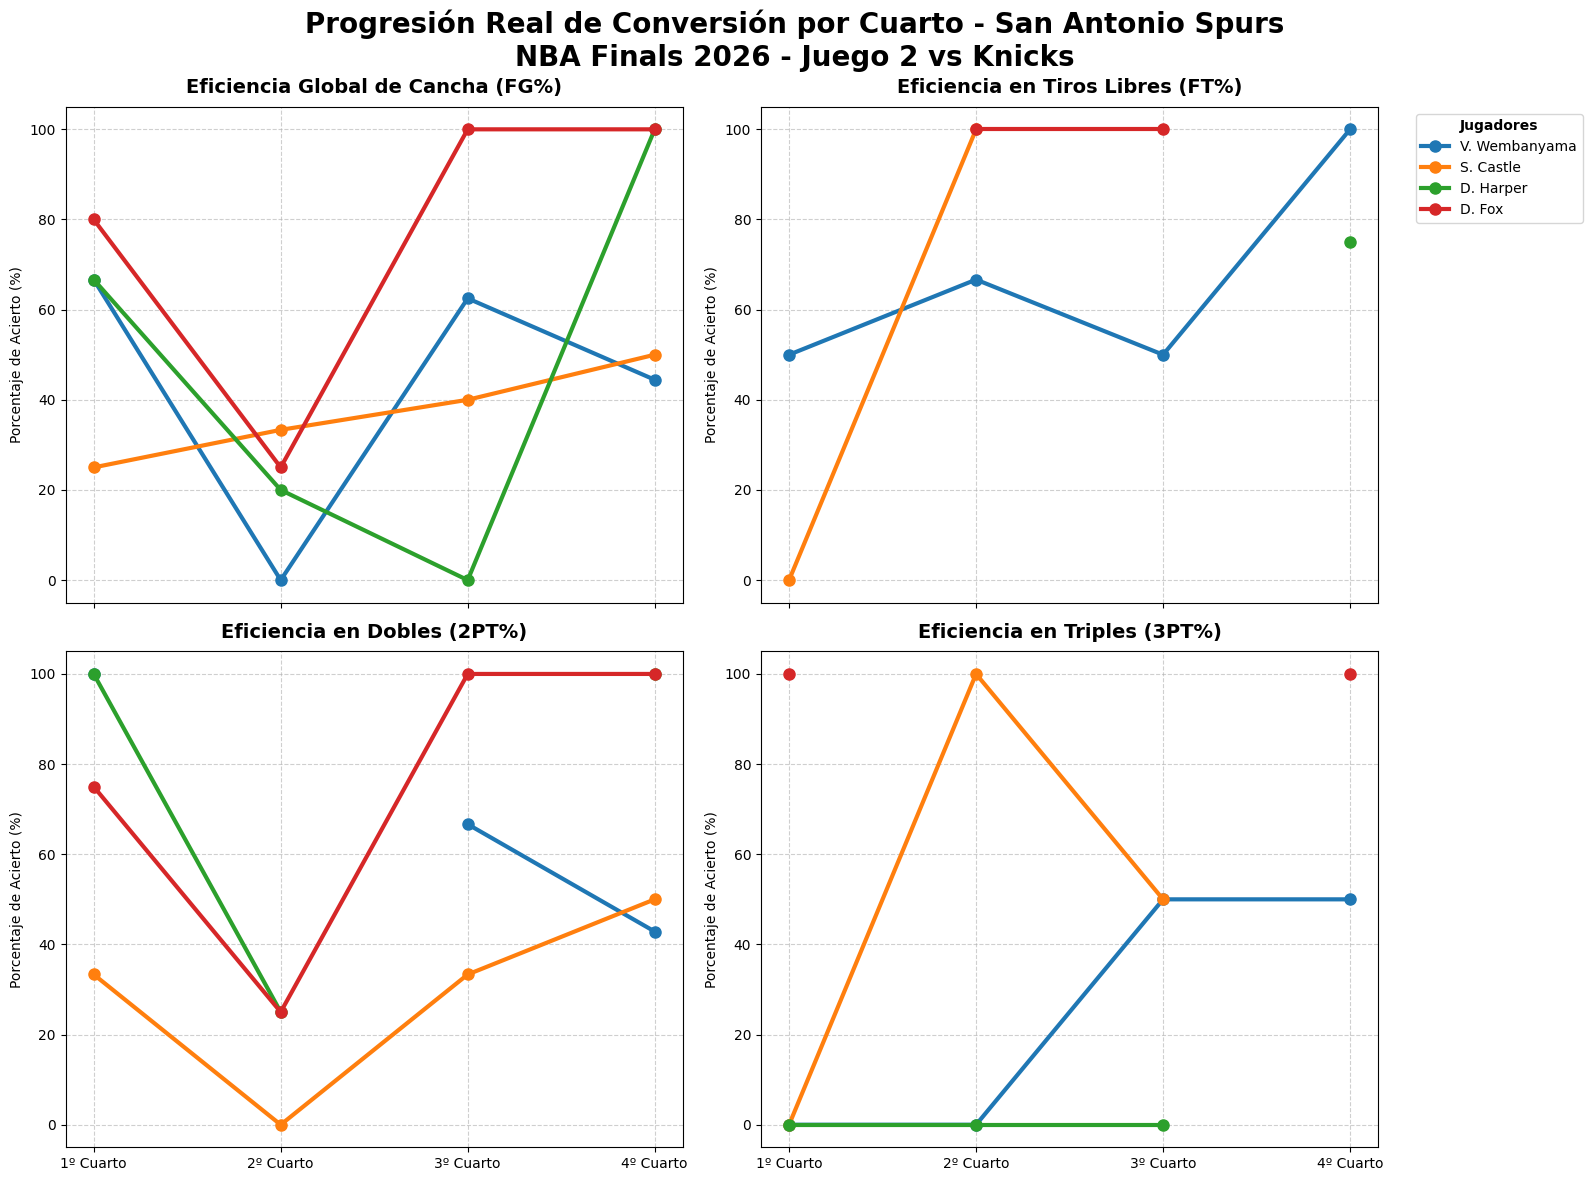

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from nba_api.stats.endpoints import playbyplayv3
from nba_api.stats.static import teams

# 1. Configuración de IDs y descarga limpia
SPURS_ID = teams.find_teams_by_full_name('San Antonio Spurs')[0]['id']
GAME_ID = '0042500402'

pbp = playbyplayv3.PlayByPlayV3(game_id=GAME_ID)
df = pd.DataFrame(pbp.get_dict()['game']['actions'])

# Filtrar por los Spurs
df_spurs = df[df['teamId'] == SPURS_ID].copy()

# 2. Clasificación matemática usando las columnas nativas de la API V3
def clasificar_tiro_v3(row):
    action = str(row.get('actionType', ''))

    # Identificar Tiros Libres
    if action == 'Free Throw':
        return 'FT'

    # Identificar Tiros de Campo usando la bandera nativa de la NBA
    if row.get('isFieldGoal') == 1:
        val = row.get('shotValue')
        if val == 3:
            return '3PT'
        if val == 2:
            return '2PT'

    return 'Otro'

df_spurs['TIPO'] = df_spurs.apply(clasificar_tiro_v3, axis=1)

# --- CORRECCIÓN DEFINITIVA DE ACUERDOS SEGÚN TU AUDITORÍA ---
def determinar_acierto_v3(row):
    if row['TIPO'] in ['2PT', '3PT']:
        return 1 if row.get('shotResult') == 'Made' else 0

    if row['TIPO'] == 'FT':
        desc = str(row.get('description', '')).upper()
        sub_type = str(row.get('subType', '')).upper()

        # Basado en tus datos, si contiene 'MISS', el libre fue errado (0)
        if 'MISS' in desc or 'MISS' in sub_type:
            return 0
        return 1 # Si no dice 'MISS', es un punto adentro

    return 0

df_spurs['ANOTADO'] = df_spurs.apply(determinar_acierto_v3, axis=1)

# Filtrar filas para quedarnos solo con intentos reales y nombres válidos
df_tiros = df_spurs[df_spurs['TIPO'].isin(['2PT', '3PT', 'FT'])].dropna(subset=['playerNameI'])

# Los 4 jugadores con más volumen reales en cancha
top_jugadores = ['V. Wembanyama', 'S. Castle', 'D. Harper', 'D. Fox']

# 3. Construcción del tablero de gráficos (2x2)
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True)

cuartos = [1, 2, 3, 4]
metrics = [
    ('FG%', ['2PT', '3PT'], 'Eficiencia Global de Cancha (FG%)'),
    ('FT%', ['FT'], 'Eficiencia en Tiros Libres (FT%)'),
    ('2PT%', ['2PT'], 'Eficiencia en Dobles (2PT%)'),
    ('3PT%', ['3PT'], 'Eficiencia en Triples (3PT%)')
]

for idx, (tipo, clases, titulo) in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]

    for jugador in top_jugadores:
        df_player = df_tiros[df_tiros['playerNameI'] == jugador]
        df_metric = df_player[df_player['TIPO'].isin(clases)]

        progresion = []
        for q in cuartos:
            df_q = df_metric[df_metric['period'] == q]
            intentos = len(df_q)
            anotados = df_q['ANOTADO'].sum()

            # Calcular porcentaje si tiró en ese cuarto
            pct = (anotados / intentos * 100) if intentos > 0 else None
            progresion.append(pct)

        ax.plot(cuartos, progresion, marker='o', linewidth=3, markersize=8, label=jugador)

    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=10)
    ax.set_ylabel('Porcentaje de Acierto (%)')
    ax.set_ylim(-5, 105)
    ax.set_xticks(cuartos)
    ax.set_xticklabels(['1º Cuarto', '2º Cuarto', '3º Cuarto', '4º Cuarto'])
    ax.grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Progresión Real de Conversión por Cuarto - San Antonio Spurs\nNBA Finals 2026 - Juego 2 vs Knicks', fontsize=20, fontweight='bold', y=0.98)
axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Jugadores", title_fontproperties={'weight':'bold'})

plt.tight_layout()
plt.show()

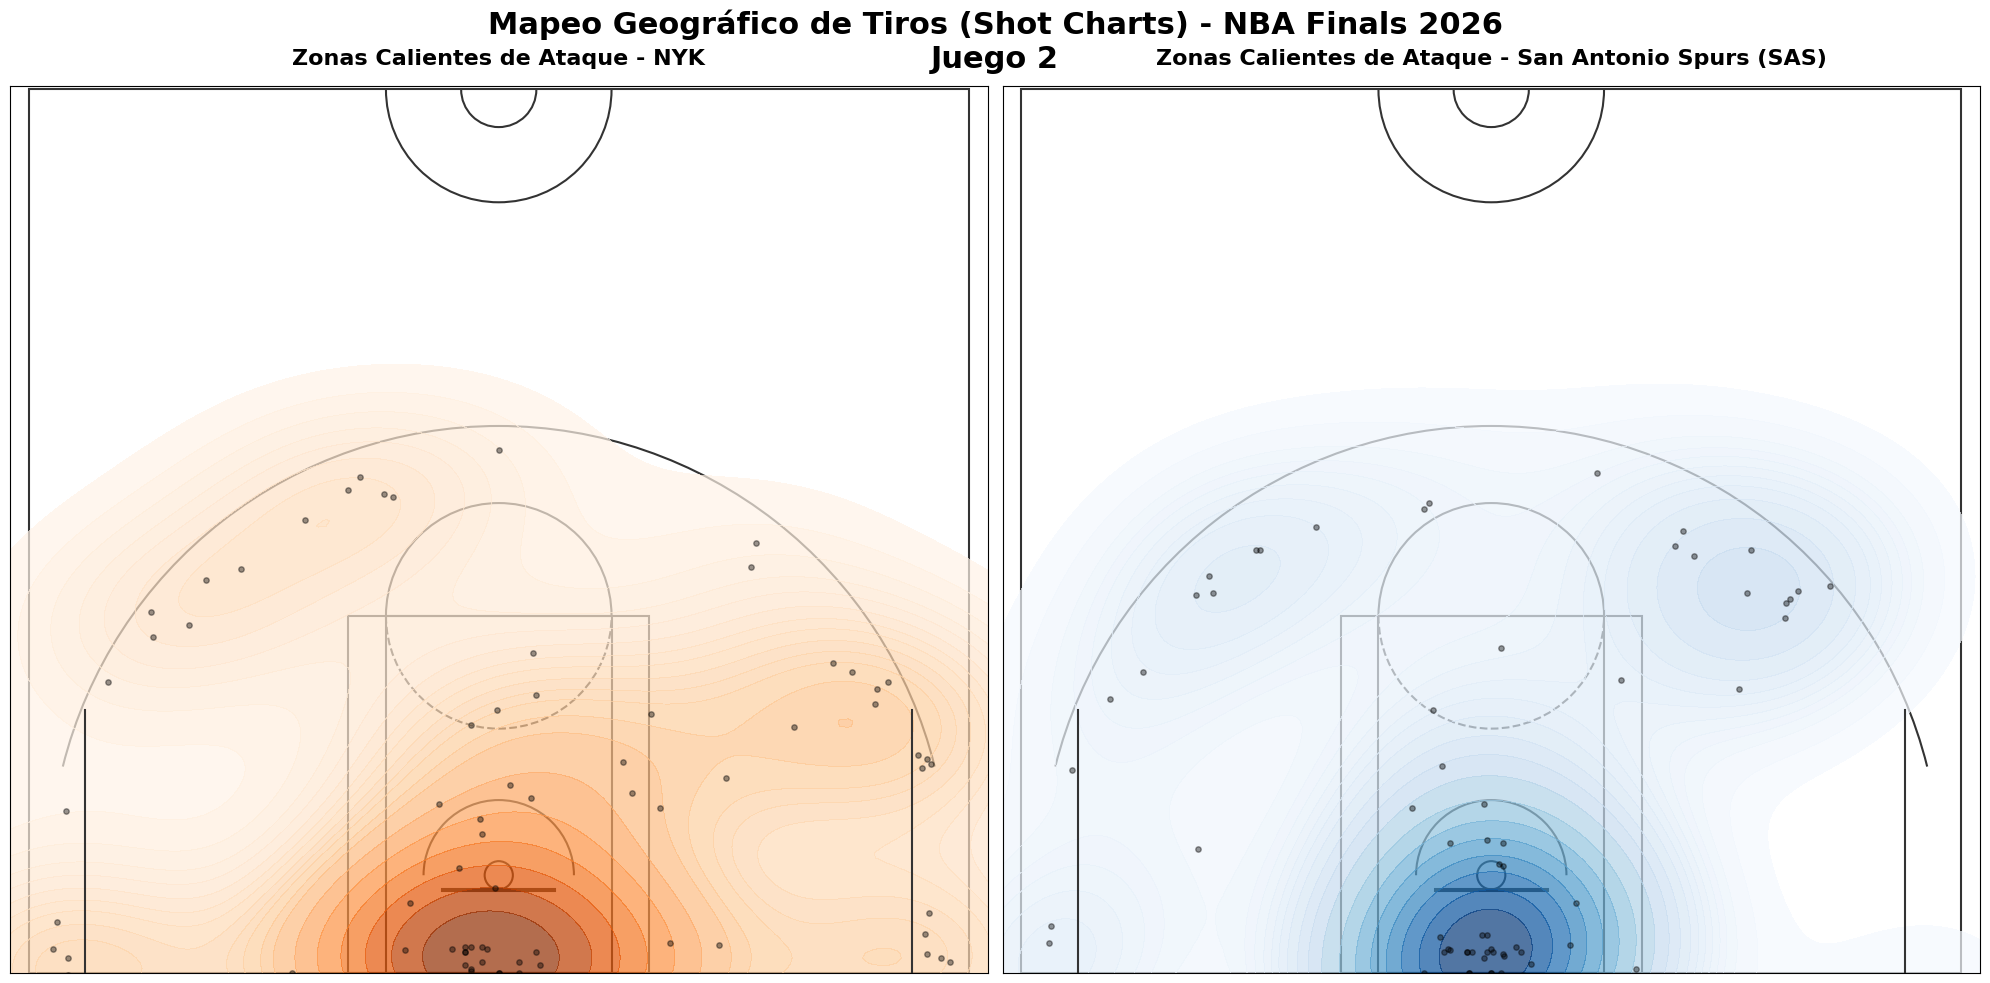

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Circle, Rectangle, Arc
from nba_api.stats.endpoints import playbyplayv3
from nba_api.stats.static import teams

# 1. Función matemática para dibujar la cancha oficial de la NBA
def dibujar_cancha(ax=None, color='black', lw=2):
    if ax is None:
        ax = plt.gca()

    # Aro (Radio de 9 pulgadas -> 0.75 pies)
    aro = Circle((0, 0), radius=0.75, linewidth=lw, color=color, fill=False)
    # Tablero (6 pies de ancho)
    tablero = Rectangle((-3, -0.75), 6, -0.1, linewidth=lw, color=color)

    # Zona Pintada (16 pies de ancho, 19 pies de largo)
    caja_externa = Rectangle((-8, -5.2), 16, 19, linewidth=lw, color=color, fill=False)
    caja_interna = Rectangle((-6, -5.2), 12, 19, linewidth=lw, color=color, fill=False)

    # Arco de Tiro Libre (Radio de 6 pies)
    arco_tiro_libre_top = Arc((0, 13.8), 12, 12, theta1=0, theta2=180, linewidth=lw, color=color, fill=False)
    arco_tiro_libre_bottom = Arc((0, 13.8), 12, 12, theta1=180, theta2=360, linewidth=lw, color=color, linestyle='--', fill=False)

    # Arco de Restricción de Carga (Radio de 4 pies)
    zona_carga = Arc((0, 0), 8, 8, theta1=0, theta2=180, linewidth=lw, color=color, fill=False)

    # Línea de Tres Puntos (NBA: esquinas rectas a 14 pies del fondo, arco a 23.9 pies del aro)
    lineas_esquina_izq = Rectangle((-22, -5.2), 0, 14, linewidth=lw, color=color)
    lineas_esquina_der = Rectangle((22, -5.2), 0, 14, linewidth=lw, color=color)
    arco_triple = Arc((0, 0), 47.8, 47.8, theta1=14, theta2=166, linewidth=lw, color=color, fill=False)

    # Línea de media cancha y contorno de la mitad de cancha
    contorno = Rectangle((-25, -5.2), 50, 47, linewidth=lw, color=color, fill=False)
    centro_externo = Arc((0, 41.8), 12, 12, theta1=180, theta2=360, linewidth=lw, color=color, fill=False)
    centro_interno = Arc((0, 41.8), 4, 4, theta1=180, theta2=360, linewidth=lw, color=color, fill=False)

    # Agregar parches al eje
    elementos = [aro, tablero, caja_externa, caja_interna, arco_tiro_libre_top,
                 arco_tiro_libre_bottom, zona_carga, arco_triple, contorno, centro_externo, centro_interno]
    for el in elementos:
        ax.add_patch(el)

    ax.plot([-22, -22], [-5.2, 8.8], color=color, linewidth=lw)
    ax.plot([22, 22], [-5.2, 8.8], color=color, linewidth=lw)

    # Restricciones de vista para centrar la media cancha de ataque
    ax.set_xlim(-26, 26)
    ax.set_ylim(-5.2, 42)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

# 2. Descarga y preparación de coordenadas espaciales
GAME_ID = '0042500402'
pbp = playbyplayv3.PlayByPlayV3(game_id=GAME_ID)
df = pd.DataFrame(pbp.get_dict()['game']['actions'])

# Filtrar solo jugadas que sean lanzamientos legítimos (isFieldGoal == 1)
df_tiros = df[df['isFieldGoal'] == 1].copy()

# En la API V3, las coordenadas a veces necesitan normalizarse.
# xLegacy y yLegacy se mapean centrando el aro en (0,0) para la visualización estándar.
df_tiros['x'] = pd.to_numeric(df_tiros['xLegacy']) / 10
df_tiros['y'] = pd.to_numeric(df_tiros['yLegacy']) / 10 - 5.2

# Identificar los dos equipos participando
SPURS_ID = teams.find_teams_by_full_name('San Antonio Spurs')[0]['id']
df_spurs = df_tiros[df_tiros['teamId'] == SPURS_ID]
df_rival = df_tiros[df_tiros['teamId'] != SPURS_ID]

tricode_spurs = df_spurs['teamTricode'].dropna().unique()[0] if not df_spurs.empty else 'SAS'
tricode_rival = df_rival['teamTricode'].dropna().unique()[0] if not df_rival.empty else 'RIV'

# 3. Construcción de la gráfica en paralelo (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# --- MAPA DE CALOR: RIVAL (NEW YORK KNICKS) ---
ax1.set_title(f'Zonas Calientes de Ataque - {tricode_rival}', fontsize=16, fontweight='bold', pad=15)
dibujar_cancha(ax1, color='#333333', lw=1.5)
if len(df_rival) > 5:
    sns.kdeplot(data=df_rival, x='x', y='y', cmap='Oranges', fill=True,
                thresh=0.05, alpha=0.7, levels=20, ax=ax1, warn_singular=False)
# Pintamos los puntos de los tiros arriba del mapa para dar contexto
ax1.scatter(df_rival['x'], df_rival['y'], color='black', s=15, alpha=0.4, label='Intentos de tiro')

# --- MAPA DE CALOR: SAN ANTONIO SPURS ---
ax2.set_title(f'Zonas Calientes de Ataque - San Antonio Spurs ({tricode_spurs})', fontsize=16, fontweight='bold', pad=15)
dibujar_cancha(ax2, color='#333333', lw=1.5)
if len(df_spurs) > 5:
    sns.kdeplot(data=df_spurs, x='x', y='y', cmap='Blues', fill=True,
                thresh=0.05, alpha=0.7, levels=20, ax=ax2, warn_singular=False)
ax2.scatter(df_spurs['x'], df_spurs['y'], color='black', s=15, alpha=0.4)

plt.suptitle('Mapeo Geográfico de Tiros (Shot Charts) - NBA Finals 2026\nJuego 2', fontsize=22, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

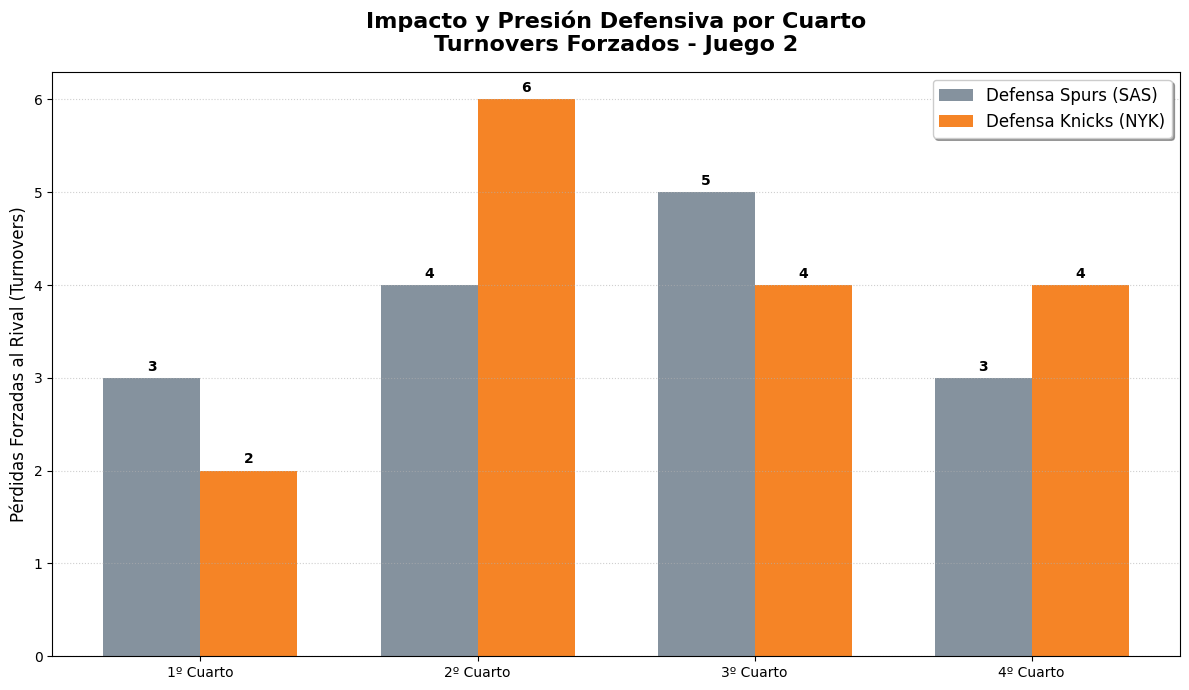

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from nba_api.stats.endpoints import playbyplayv3
from nba_api.stats.static import teams

# 1. Descarga del flujo completo
GAME_ID = '0042500402'
pbp = playbyplayv3.PlayByPlayV3(game_id=GAME_ID)
df = pd.DataFrame(pbp.get_dict()['game']['actions'])

# 2. Identificar equipos
SPURS_ID = teams.find_teams_by_full_name('San Antonio Spurs')[0]['id']

# Encontrar el tricode del rival (Knicks)
tricodes = df['teamTricode'].dropna().unique()
tricode_spurs = df[df['teamId'] == SPURS_ID]['teamTricode'].dropna().unique()[0]
tricode_rival = [t for t in tricodes if t != tricode_spurs and t != ''][0]

# 3. Filtrar todas las pérdidas de balón (Turnovers)
# Esto incluye robos recibidos, pases malos, violaciones, etc.
df_tov = df[df['actionType'] == 'Turnover'].copy()

# Si el teamId es de los Spurs, la pérdida es de SAS (puntos para la defensa de NYK)
# Si el teamId es del rival, la pérdida es de NYK (puntos para la defensa de SAS)
df_tov['Defensa_Provocadora'] = df_tov['teamId'].apply(lambda x: tricode_spurs if x != SPURS_ID else tricode_rival)

# 4. Agrupar por cuarto y por equipo defensivo
cuartos = [1, 2, 3, 4]
defensa_spurs = []
defensa_rival = []

for q in cuartos:
    df_q = df_tov[df_tov['period'] == q]

    # Cuántas pérdidas provocó cada defensa en este cuarto
    tov_provocados_spurs = len(df_q[df_q['Defensa_Provocadora'] == tricode_spurs])
    tov_provocados_rival = len(df_q[df_q['Defensa_Provocadora'] == tricode_rival])

    defensa_spurs.append(tov_provocados_spurs)
    defensa_rival.append(tov_provocados_rival)

# 5. Graficar el volumen defensivo (Pérdidas Provocadas)
import numpy as np
x = np.arange(len(cuartos))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

rects1 = ax.bar(x - width/2, defensa_spurs, width, label=f'Defensa Spurs ({tricode_spurs})', color='#85929E')
rects2 = ax.bar(x + width/2, defensa_rival, width, label=f'Defensa Knicks ({tricode_rival})', color='#F58426')

# Añadir textos y etiquetas estéticas
ax.set_ylabel('Pérdidas Forzadas al Rival (Turnovers)', fontsize=12)
ax.set_title('Impacto y Presión Defensiva por Cuarto\nTurnovers Forzados - Juego 2', fontsize=16, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(['1º Cuarto', '2º Cuarto', '3º Cuarto', '4º Cuarto'])
ax.grid(True, linestyle=':', alpha=0.6, axis='y')
ax.legend(fontsize=12, shadow=True)

# Función para poner los números arriba de las barras
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

In [28]:
import pandas as pd
from nba_api.stats.endpoints import playbyplayv3

GAME_ID = '0042500402'
pbp = playbyplayv3.PlayByPlayV3(game_id=GAME_ID)
df = pd.DataFrame(pbp.get_dict()['game']['actions'])

# Buscamos cualquier columna que contenga la palabra 'assist' o 'player' para ver el nombre real
columnas_asistencia = [c for c in df.columns if 'assist' in c.lower() or 'player' in c.lower()]
print("--- COLUMNAS DE ASISTENCIA ENCONTRADAS ---")
print(columnas_asistencia)

--- COLUMNAS DE ASISTENCIA ENCONTRADAS ---
['playerName', 'playerNameI']


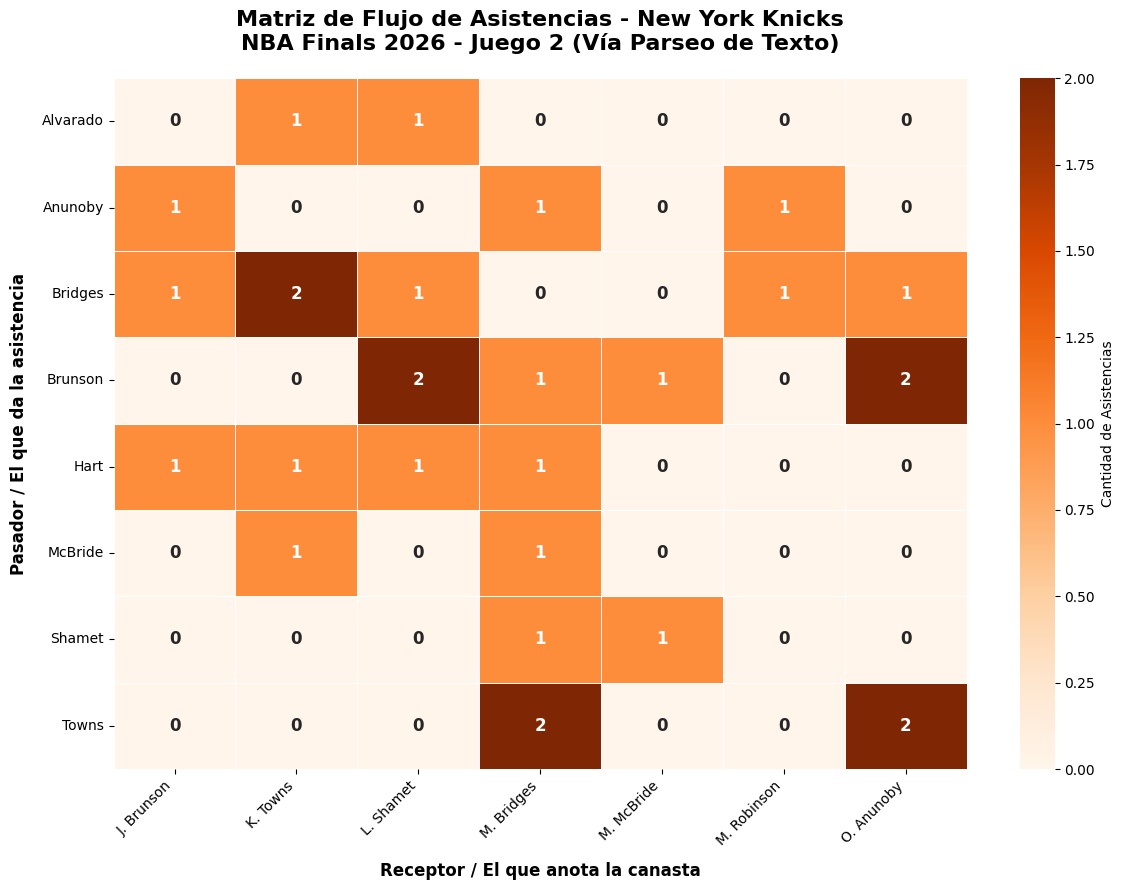

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from nba_api.stats.endpoints import playbyplayv3
from nba_api.stats.static import teams

# 1. Descarga limpia del partido completo
GAME_ID = '0042500402'
pbp = playbyplayv3.PlayByPlayV3(game_id=GAME_ID)
df = pd.DataFrame(pbp.get_dict()['game']['actions'])

# Identificar el ID de los Knicks para aislar su ofensiva
KNICKS_ID = teams.find_teams_by_full_name('New York Knicks')[0]['id']
df_knicks = df[df['teamId'] == KNICKS_ID].copy()

# Filtrar solo tiros convertidos (Made Shot) de los Knicks
df_made = df_knicks[
    (df_knicks['isFieldGoal'] == 1) &
    (df_knicks['shotResult'] == 'Made')
].copy()

# 2. Extracción analítica del asistente usando Expresiones Regulares (Regex)
# Buscamos el patrón típico de la NBA: "(Apellido_Jugador X AST)" dentro de la descripción
def extraer_asistente_desde_desc(desc_str):
    desc_str = str(desc_str)
    # Patrón: busca una palabra seguida de un espacio y las letras AST entre paréntesis
    match = re.search(r'\(([\w\s\.\-]+)\s+\d+\s+AST\)', desc_str)
    if match:
        return match.group(1).strip()
    return None

df_made['Asistente_Extraido'] = df_made['description'].apply(extraer_asistente_desde_desc)

# Nos quedamos solo con las jugadas que efectivamente tuvieron asistencia
df_asistencias_reales = df_made.dropna(subset=['Asistente_Extraido']).copy()

# 3. Construcción de la matriz de doble entrada
# Filas: El que da el pase (Asistente) | Columnas: El que define (Anotador)
matriz_pases = pd.crosstab(
    df_asistencias_reales['Asistente_Extraido'],
    df_asistencias_reales['playerNameI']
)

# 4. Graficar la Matriz de Flujo con Seaborn
if not matriz_pases.empty:
    plt.figure(figsize=(12, 9))

    sns.heatmap(
        matriz_pases,
        annot=True,          # Números enteros dentro de cada celda
        cmap='Oranges',      # Identidad visual de los Knicks
        fmt='d',
        linewidths=.5,
        cbar_kws={'label': 'Cantidad de Asistencias'},
        annot_kws={'weight': 'bold', 'size': 12}
    )

    plt.title('Matriz de Flujo de Asistencias - New York Knicks\nNBA Finals 2026 - Juego 2 (Vía Parseo de Texto)', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Receptor / El que anota la canasta', fontsize=12, fontweight='bold', labelpad=10)
    plt.ylabel('Pasador / El que da la asistencia', fontsize=12, fontweight='bold', labelpad=10)

    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Muestra de descripciones para auditar por qué no se detectaron AST:")
    print(df_made['description'].head(10))

In [31]:
import pandas as pd
import re
from nba_api.stats.endpoints import playbyplayv3

# 1. Descarga del flujo completo del partido
GAME_ID = '0042500402'
pbp = playbyplayv3.PlayByPlayV3(game_id=GAME_ID)
df = pd.DataFrame(pbp.get_dict()['game']['actions'])

# 2. Inicializar diccionarios para almacenar la estadística avanzada por jugador
stats = {}

def registrar_jugador(nombre, equipo):
    # CORREGIDO: Se cambió 'not block_tools' por 'not in block_tools'
    if nombre and nombre not in block_tools and nombre not in stats:
        stats[nombre] = {
            'Equipo': equipo, '2PT_M': 0, '2PT_A': 0,
            '3PT_M': 0, '3PT_A': 0, 'FT_M': 0, 'FT_A': 0, 'AST': 0
        }

block_tools = [None, '', 'None', 'TEAM', 'Unknown']

# 3. Procesamiento analítico línea por línea del Play-by-Play
for _, row in df.iterrows():
    desc = str(row.get('description', ''))
    action = str(row.get('actionType', ''))
    sub_type = str(row.get('subType', ''))
    jugador = row.get('playerNameI')
    equipo = row.get('teamTricode')

    if not equipo or equipo == '':
        continue

    # --- A) PARSEO DE TIROS DE CAMPO (Dobles y Triples) ---
    if row.get('isFieldGoal') == 1:
        registrar_jugador(jugador, equipo)
        val = row.get('shotValue')
        es_triple = (val == 3)
        anotado = (row.get('shotResult') == 'Made')

        if es_triple:
            stats[jugador]['3PT_A'] += 1
            if anotado: stats[jugador]['3PT_M'] += 1
        else:
            stats[jugador]['2PT_A'] += 1
            if anotado: stats[jugador]['2PT_M'] += 1

        # Rastrear Asistencias dentro del texto de la conversión
        if anotado:
            match_ast = re.search(r'\(([\w\s\.\-]+)\s+\d+\s+AST\)', desc)
            if match_ast:
                asistente = match_ast.group(1).strip()
                registrar_jugador(asistente, equipo)
                stats[asistente]['AST'] += 1

    # --- B) PARSEO DE TIROS LIBRES ---
    elif action == 'Free Throw':
        registrar_jugador(jugador, equipo)
        stats[jugador]['FT_A'] += 1
        if 'MISS' not in desc.upper() and 'MISS' not in sub_type.upper():
            stats[jugador]['FT_M'] += 1

# 4. Transformación del diccionario a DataFrame y cálculo de Rates
df_box = pd.DataFrame.from_dict(stats, orient='index')

# Calcular Puntos Totales
df_box['PTS'] = (df_box['2PT_M'] * 2) + (df_box['3PT_M'] * 3) + df_box['FT_M']

# Calcular Porcentajes de Conversión
df_box['2PT%'] = (df_box['2PT_M'] / df_box['2PT_A'] * 100).round(1).fillna(0).astype(str) + '%'
df_box['3PT%'] = (df_box['3PT_M'] / df_box['3PT_A'] * 100).round(1).fillna(0).astype(str) + '%'
df_box['FT%'] = (df_box['FT_M'] / df_box['FT_A'] * 100).round(1).fillna(0).astype(str) + '%'

# Crear columnas de visualización clásica tipo "Metidos-Intentados"
df_box['2PT (M-A)'] = df_box['2PT_M'].astype(str) + '-' + df_box['2PT_A'].astype(str)
df_box['3PT (M-A)'] = df_box['3PT_M'].astype(str) + '-' + df_box['3PT_A'].astype(str)
df_box['FT (M-A)'] = df_box['FT_M'].astype(str) + '-' + df_box['FT_A'].astype(str)

# Limpiar y ordenar las columnas para la presentación
columnas_finales = ['Equipo', 'PTS', 'AST', '2PT (M-A)', '2PT%', '3PT (M-A)', '3PT%', 'FT (M-A)', 'FT%']
df_box_final = df_box[columnas_finales].sort_values(by=['Equipo', 'PTS'], ascending=[True, False])

# 5. Mostrar resultados divididos por equipo
print("="*50 + "\n BOX SCORE: NEW YORK KNICKS\n" + "="*50)
print(df_box_final[df_box_final['Equipo'] == 'NYK'].to_string())

print("\n" + "="*50 + "\n BOX SCORE: SAN ANTONIO SPURS\n" + "="*50)
print(df_box_final[df_box_final['Equipo'] == 'SAS'].to_string())

 BOX SCORE: NEW YORK KNICKS
            Equipo  PTS  AST 2PT (M-A)    2PT% 3PT (M-A)   3PT% FT (M-A)     FT%
K. Towns       NYK   21    0       5-7   71.4%       3-5  60.0%      2-2  100.0%
J. Brunson     NYK   20    0      5-17   29.4%       2-8  25.0%      4-5   80.0%
M. Bridges     NYK   20    0       4-7   57.1%       4-6  66.7%      0-0    0.0%
O. Anunoby     NYK   17    0       3-5   60.0%       2-5  40.0%      5-5  100.0%
L. Shamet      NYK   13    0       2-5   40.0%       3-7  42.9%      0-0    0.0%
M. Robinson    NYK    7    0       2-2  100.0%       0-0   0.0%      3-6   50.0%
M. McBride     NYK    5    0       1-4   25.0%       1-3  33.3%      0-0    0.0%
J. Alvarado    NYK    2    0       0-2    0.0%       0-2   0.0%      2-3   66.7%
Towns          NYK    0    4       0-0    0.0%       0-0   0.0%      0-0    0.0%
Brunson        NYK    0    6       0-0    0.0%       0-0   0.0%      0-0    0.0%
J. Hart        NYK    0    0       0-2    0.0%       0-2   0.0%      0-0    0.0%
